In [2]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [3]:
from langchain_openai import ChatOpenAI

In [48]:
llm = ChatOpenAI(model_name="gpt-4o", temperature=0)

In [49]:
print(llm.invoke("What is the capital of France?").content)

The capital of France is Paris.


In [50]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
search_tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

In [51]:
search_tool.invoke("What is the capital of France?")

[{'title': 'France | History, Maps, Flag, Population, Cities, Capital, & Facts',
  'url': 'https://www.britannica.com/place/France',
  'content': "Historically, the Francien dialect became the official language in 1539, eventually replacing Latin and other dialects. Although regional languages were once discouraged, they have been reintroduced in some schools because several have maintained literary traditions. Today, French is considered one of the most internationally significant Romance languages.\n\n  3 Britannica Sources\n\n  1. France: Country Facts\n  2. Valentin Conrart\n  3. French language: History\n\n  This answer is created from Britannica articles using AI. AI can make mistakes, so verify using Britannica articles.\n What is the capital city of France and why is it famous?\n\n  The capital of France is Paris. Situated in the north-central part of the country, Paris is France's center of commerce and culture. [...] The capital and by far the most important city of France is

In [52]:
my_code = """
x=10
y=x+10
print(y)
"""

In [53]:
!pip install langchain_experimental

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
from langchain_experimental.utilities import PythonREPL

In [55]:
repl=PythonREPL()

In [56]:
repl.invoke(my_code)

AttributeError: 'PythonREPL' object has no attribute 'invoke'

In [57]:
repl.run(my_code)

'20\n'

In [58]:
from typing import Annotated

In [59]:
from langchain_core.tools import tool

In [60]:
@tool
def python_repl_tool(code: Annotated[str, "The python code to execute to generate your chart."]):
    """Use this to execute python code and do math. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return result_str

<>:11: SyntaxWarning: "\`" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\`"? A raw string is also an option.
<>:11: SyntaxWarning: "\`" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\`"? A raw string is also an option.
<>:11: SyntaxWarning: "\`" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\`"? A raw string is also an option.
<>:11: SyntaxWarning: "\`" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\`"? A raw string is also an option.
C:\Users\DELL\AppData\Local\Temp\ipykernel_10024\2860116823.py:11: SyntaxWarning: "\`" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\`"? A raw string is also an option.
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
C:\Users\DELL\AppData\Local\Temp\ipykernel_10024\2860116823.py:11: SyntaxWarning:

In [61]:
python_repl_tool.invoke("x=10\ny=x+10\nprint(y)")

'Successfully executed:\n\\`\\`\\`python\nx=10\ny=x+10\nprint(y)\n\\`\\`\\`\nStdout: 20\n'

### WE HAVE TWO SUB AGENT 
1. RESEARCHER- internet
2. CODER- executing the code

In [62]:
members=["researcher","coder"]

In [63]:
options = members+["FINISH"]

In [64]:
options

['researcher', 'coder', 'FINISH']

In [65]:
from typing import Literal

In [66]:
from typing_extensions import TypedDict

In [67]:
class Router(TypedDict):
    next: Literal['researcher', 'coder', 'FINISH']

In [68]:
from langgraph.graph import MessagesState,StateGraph,START, END
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

In [69]:
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [70]:
class State(MessagesState):
    next:str

In [71]:
state={"messages": ["hi"], "next": "research_agent"}

In [72]:
system_prompt = f""""
You are a supervisor, tasked with managing a conversation between the following workers: {members}. 
Given the following user request, respond with the worker to act next. 
Each worker will perform a task and respond with their results and status. 
When finished, respond with FINISH.
"""

In [73]:
messages = [{"role": "system", "content": system_prompt},] + state["messages"]

In [74]:
messages

[{'role': 'system',
  'content': '"\nYou are a supervisor, tasked with managing a conversation between the following workers: [\'researcher\', \'coder\']. \nGiven the following user request, respond with the worker to act next. \nEach worker will perform a task and respond with their results and status. \nWhen finished, respond with FINISH.\n'},
 'hi']

In [75]:
llm_with_structure_output=llm.with_structured_output(Router)

In [76]:
llm_with_structure_output.invoke(messages)

{'next': 'researcher'}

In [77]:
from langgraph.types import Command

In [78]:
def supervisor_agent(state:State)->Command[Literal['researcher', 'coder', '__end__']]:
    
    messages = [{"role": "system", "content": system_prompt},] + state["messages"]
    
    llm_with_structure_output=llm.with_structured_output(Router)
    
    response=llm_with_structure_output.invoke(messages)
    
    #this is my response {'next': 'researcher'}
    
    #this is my next worker agent
    goto=response["next"]
    
    print("**********BELOW IS MY GOTO***************")
    
    print(goto)
    
    if goto == "FINISH":
        goto=END
    
    # class State(MessagesState):
    #   next:str
    # output of the state: state={"messages": ["hi"], "next": "researcher"}
    
    return Command(goto=goto, update={"next":goto})

In [79]:
from langgraph.prebuilt import create_react_agent

In [80]:
from langchain_core.messages import AIMessage, HumanMessage

In [81]:
def research_agent(state: State) -> Command[Literal["supervisor"]]:
    
    research_agent = create_react_agent(llm, tools=[search_tool], prompt="You are a researcher. DO NOT do any math.")
    
    result=research_agent.invoke(state)
    
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="researcher")
            ]
        },
        goto="supervisor",
    )
    

In [82]:
def coder_agent(state:State)->Command[Literal['supervisor']]:
    code_agent=create_react_agent(llm,tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")
    result=code_agent.invoke(state)
    
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="coder")
            ]
        },
        goto="supervisor",
    )
    

In [83]:
graph=StateGraph(State)

In [84]:
graph.add_node("supervisor", supervisor_agent)

In [85]:
graph.add_node("researcher", research_agent)

In [86]:
graph.add_node("coder", coder_agent)

In [87]:
graph.add_edge(START, "supervisor")

In [88]:
app=graph.compile()

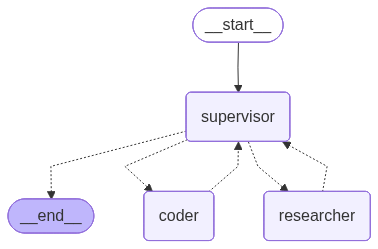

In [89]:
app

In [90]:
for s in app.stream({"messages": [("user", "What's the square root of 42?")]}, subgraphs=True):
    print(s)
    print("**********BELOW IS MY STATE***************")

**********BELOW IS MY GOTO***************
coder
((), {'supervisor': {'next': 'coder'}})
**********BELOW IS MY STATE***************


C:\Users\DELL\AppData\Local\Temp\ipykernel_10024\2396260197.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent=create_react_agent(llm,tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")


(('coder:aadc35a8-7203-9f04-949f-bd1cf665a3fb',), {'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 107, 'total_tokens': 130, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f38a9d6fcb', 'id': 'chatcmpl-DvgYtTpV9BM85stSj5HbTXRvqzsow', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f0daa-0755-76b3-9ffe-a910518a8b27-0', tool_calls=[{'name': 'python_repl_tool', 'args': {'code': 'import math\nmath.sqrt(42)'}, 'id': 'call_IKj8oZApkJqNcOpR7X6A1iwd', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 107, 'output_tokens': 23, 'total_tokens': 130, 'input_token_details': {'

In [91]:
result=app.invoke({"messages": [("user", "what is an efficent python code to get prime number?")]}, subgraphs=True)


**********BELOW IS MY GOTO***************
researcher


C:\Users\DELL\AppData\Local\Temp\ipykernel_10024\2060188370.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(llm, tools=[search_tool], prompt="You are a researcher. DO NOT do any math.")


**********BELOW IS MY GOTO***************
coder


C:\Users\DELL\AppData\Local\Temp\ipykernel_10024\2396260197.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent=create_react_agent(llm,tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")


**********BELOW IS MY GOTO***************
FINISH


In [92]:
result

{'messages': [HumanMessage(content='what is an efficent python code to get prime number?', additional_kwargs={}, response_metadata={}, id='a08f7af7-6801-42a2-bcdf-83447776cccc'),
  HumanMessage(content="To find prime numbers efficiently in Python, you can use the Sieve of Eratosthenes algorithm. This algorithm is efficient for finding all prime numbers up to a specified integer. Here's a simple implementation:\n\n```python\ndef sieve_of_eratosthenes(n):\n    primes = []\n    is_prime = [True] * (n + 1)\n    p = 2\n    while p * p <= n:\n        if is_prime[p]:\n            for i in range(p * p, n + 1, p):\n                is_prime[i] = False\n        p += 1\n    for p in range(2, n + 1):\n        if is_prime[p]:\n            primes.append(p)\n    return primes\n\n# Example usage:\nn = 100\nprime_numbers = sieve_of_eratosthenes(n)\nprint(prime_numbers)\n```\n\nThis code defines a function `sieve_of_eratosthenes` that takes an integer `n` and returns a list of all prime numbers up to `n`